# Chapter 16 — Resampling

Bootstrap and permutation methods for when formulas run out.

| Section | What it covers |
|---|---|
| 16.1 | The bootstrap |
| 16.2 | Permutation tests |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Resampling](https://khh-aka-lucifer.github.io/statLab/chapters/resampling/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## When there is no formula

Every interval so far came from a formula, and every formula came with assumptions. Those formulas
exist for means, proportions and slopes. For a median, a ratio of medians, or a trimmed mean, they
either do not exist or are horrible.

Resampling replaces the algebra with computation. You already used it in Chapter 12 without it being
named. Here it gets its name and its two main jobs.

In [2]:
penguins = pd.read_csv(DATA / "penguins.csv")
adelie = penguins.loc[penguins["species"] == "Adelie", "body_mass_g"].dropna().to_numpy()

print(f"n = {len(adelie)} Adelie penguins")
print(f"mean   {adelie.mean():.1f} g")
print(f"median {np.median(adelie):.1f} g   <- no neat formula for the standard error of this")

n = 151 Adelie penguins
mean   3700.7 g
median 3700.0 g   <- no neat formula for the standard error of this


## 16.1 The bootstrap

The idea is almost too simple. Your sample is the best picture of the population you have. So treat
it as the population, draw new samples *from it* with replacement, and watch how much your statistic
moves.

Each resample is the same size as the original. Some penguins get picked twice, some not at all, and
that is the point.

In [3]:
def bootstrap(data, statistic, reps=10_000):
    n = len(data)
    return np.array([statistic(data[rng.integers(0, n, n)]) for _ in range(reps)])

boot_median = bootstrap(adelie, np.median)
boot_mean = bootstrap(adelie, np.mean)

print(f"observed median {np.median(adelie):.1f} g")
print(f"bootstrap SE of the median: {boot_median.std(ddof=1):.1f} g")
print()
print(f"observed mean   {adelie.mean():.1f} g")
print(f"bootstrap SE of the mean:   {boot_mean.std(ddof=1):.1f} g")
print(f"formula SE of the mean:     {adelie.std(ddof=1)/np.sqrt(len(adelie)):.1f} g   <- the bootstrap reproduces it")

observed median 3700.0 g
bootstrap SE of the median: 60.3 g

observed mean   3700.7 g
bootstrap SE of the mean:   36.7 g
formula SE of the mean:     37.3 g   <- the bootstrap reproduces it


The last two lines are the sanity check that makes the rest believable. For the mean, where a formula
exists, the bootstrap recovers it to within rounding. So when it gives you a number for the median,
where no formula exists, you have grounds to trust it.

The 95 % interval is just the middle 95 % of the resampled values.

In [4]:
lo, hi = np.percentile(boot_median, [2.5, 97.5])
print(f"95% bootstrap interval for the median: ({lo:.1f}, {hi:.1f}) g")

t_lo, t_hi = stats.t.interval(0.95, len(adelie)-1, adelie.mean(),
                              adelie.std(ddof=1)/np.sqrt(len(adelie)))
b_lo, b_hi = np.percentile(boot_mean, [2.5, 97.5])
print()
print(f"for the mean, t-interval:         ({t_lo:.1f}, {t_hi:.1f}) g")
print(f"for the mean, bootstrap interval: ({b_lo:.1f}, {b_hi:.1f}) g")

95% bootstrap interval for the median: (3550.0, 3775.0) g

for the mean, t-interval:         (3626.9, 3774.4) g
for the mean, bootstrap interval: (3630.5, 3774.5) g


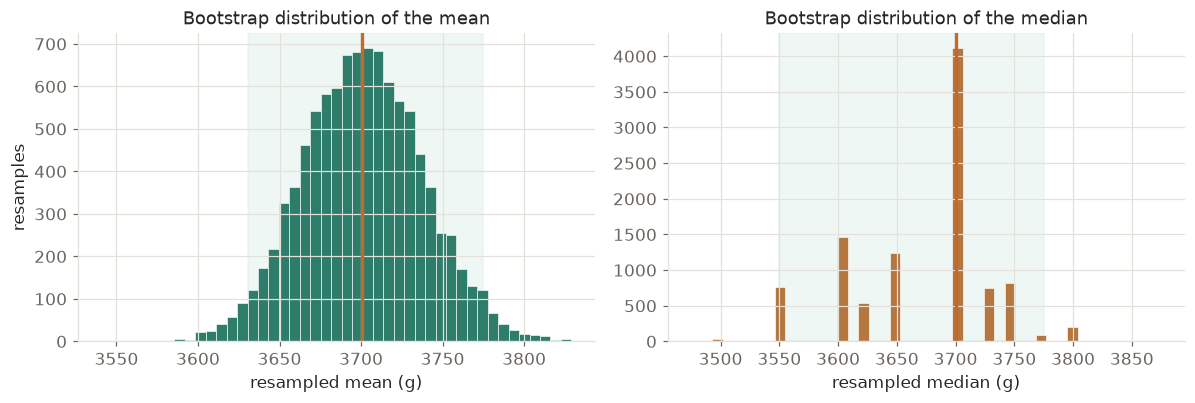

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

left.hist(boot_mean, bins=45, color=C["accent"], edgecolor="white", linewidth=0.4)
left.axvline(adelie.mean(), color=C["warn"], lw=2.2)
left.axvspan(b_lo, b_hi, color=C["accent_soft"], alpha=0.4, zorder=0)
left.set_xlabel("resampled mean (g)"); left.set_ylabel("resamples")
left.set_title("Bootstrap distribution of the mean")

right.hist(boot_median, bins=45, color=C["cat2"], edgecolor="white", linewidth=0.4)
right.axvline(np.median(adelie), color=C["warn"], lw=2.2)
right.axvspan(lo, hi, color=C["accent_soft"], alpha=0.4, zorder=0)
right.set_xlabel("resampled median (g)")
right.set_title("Bootstrap distribution of the median")

plt.tight_layout()
plt.show()

The median's bootstrap distribution is lumpy, with visible gaps. That is not a bug. The median of a
sample can only ever be one of the observed values, or the midpoint of two, so the resampled medians
land on a grid. A formula-based approach would have hidden that; the bootstrap shows it to you.

### Where the bootstrap struggles

It is not magic. It assumes your sample represents the population, so it cannot fix a biased sample.
And it does badly for statistics that depend on the extremes, because a resample can never contain a
value larger than the largest you observed.

In [6]:
boot_max = bootstrap(adelie, np.max, reps=5000)

print(f"observed maximum: {adelie.max():.0f} g")
print(f"bootstrap interval for the maximum: "
      f"({np.percentile(boot_max, 2.5):.0f}, {np.percentile(boot_max, 97.5):.0f}) g")
print()
print(f"distinct values the bootstrap ever produced: {len(np.unique(boot_max))}")
print("The interval cannot go above the largest penguin we happened to catch, which is absurd")
print("as an estimate of the largest Adelie alive. Do not bootstrap extremes.")

observed maximum: 4775 g
bootstrap interval for the maximum: (4675, 4775) g

distinct values the bootstrap ever produced: 9
The interval cannot go above the largest penguin we happened to catch, which is absurd
as an estimate of the largest Adelie alive. Do not bootstrap extremes.


In [ ]:
# Your turn.
# Bootstrap the INTERQUARTILE RANGE of Adelie body mass.
# 1. Compute a 95% interval for it.
# 2. Now bootstrap the ratio of the Gentoo median to the Adelie median.
#    There is certainly no formula for that. Give a 95% interval.

...

## 16.2 Permutation tests

The second job is testing. If a grouping label carries no information, then shuffling the labels
should change nothing. So shuffle them, many times, and see how often chance alone produces a gap as
big as yours.

Adelie against Chinstrap body mass is the right test case, because Chapter 10 found no evidence of a
difference and we can see whether a method with no assumptions agrees.

In [7]:
chinstrap = penguins.loc[penguins["species"] == "Chinstrap", "body_mass_g"].dropna().to_numpy()

observed_gap = chinstrap.mean() - adelie.mean()
print(f"Adelie    mean {adelie.mean():.1f} g  (n = {len(adelie)})")
print(f"Chinstrap mean {chinstrap.mean():.1f} g  (n = {len(chinstrap)})")
print(f"observed difference: {observed_gap:.1f} g")

Adelie    mean 3700.7 g  (n = 151)
Chinstrap mean 3733.1 g  (n = 68)
observed difference: 32.4 g


In [8]:
combined = np.concatenate([adelie, chinstrap])
n_adelie = len(adelie)

shuffled_gaps = np.empty(20_000)
for i in range(len(shuffled_gaps)):
    mixed = rng.permutation(combined)
    shuffled_gaps[i] = mixed[n_adelie:].mean() - mixed[:n_adelie].mean()

p_permutation = (np.abs(shuffled_gaps) >= abs(observed_gap)).mean()
p_welch = stats.ttest_ind(chinstrap, adelie, equal_var=False).pvalue

print(f"permutation p = {p_permutation:.4f}")
print(f"Welch t-test p = {p_welch:.4f}")
print("\nTwo very different methods, the same verdict.")

permutation p = 0.6152
Welch t-test p = 0.5879

Two very different methods, the same verdict.


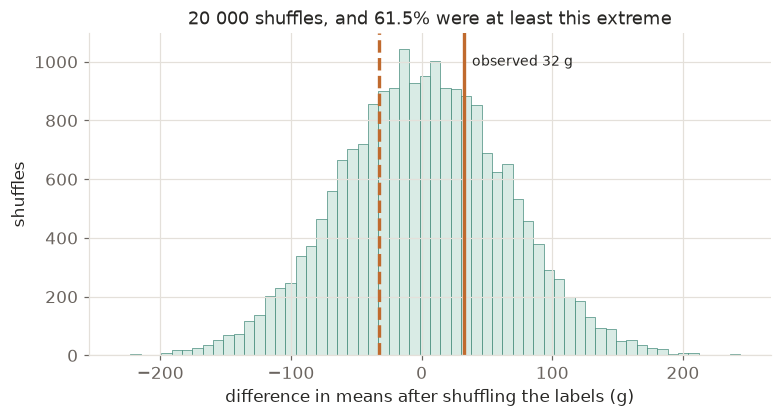

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(shuffled_gaps, bins=60, color=C["accent_soft"], edgecolor=C["accent"], linewidth=0.4)
for edge, style in [(observed_gap, "-"), (-observed_gap, "--")]:
    ax.axvline(edge, color=C["warn"], lw=2.2, ls=style)
ax.text(observed_gap, ax.get_ylim()[1]*0.9, f"  observed {observed_gap:.0f} g",
        color=C["ink"], fontsize=9)

ax.set_xlabel("difference in means after shuffling the labels (g)"); ax.set_ylabel("shuffles")
ax.set_title(f"20 000 shuffles, and {p_permutation:.1%} were at least this extreme")
plt.show()

The observed difference sits comfortably inside the pile of differences that shuffling produces, so
it is not evidence of anything.

Now run the same machinery where there *is* an effect, to see the other outcome.

In [10]:
gentoo = penguins.loc[penguins["species"] == "Gentoo", "body_mass_g"].dropna().to_numpy()

def permutation_test(a, b, reps=20_000):
    gap = b.mean() - a.mean()
    pooled = np.concatenate([a, b])
    na = len(a)
    extreme = 0
    for _ in range(reps):
        mixed = rng.permutation(pooled)
        if abs(mixed[na:].mean() - mixed[:na].mean()) >= abs(gap):
            extreme += 1
    return gap, (extreme + 1) / (reps + 1)      # +1 so p is never exactly zero

gap, p = permutation_test(adelie, gentoo)
print(f"Adelie vs Gentoo: difference {gap:.1f} g, permutation p = {p:.6f}")
print(f"                  Welch p = {stats.ttest_ind(gentoo, adelie, equal_var=False).pvalue:.3e}")
print()
print("Note the permutation p cannot go below 1/(reps+1). It is bounded by how many shuffles")
print("you ran, so 'p < 0.00005' is the honest way to report this one.")

Adelie vs Gentoo: difference 1375.4 g, permutation p = 0.000050
                  Welch p = 7.710e-65

Note the permutation p cannot go below 1/(reps+1). It is bounded by how many shuffles
you ran, so 'p < 0.00005' is the honest way to report this one.


### Why bother, when the t-test agrees?

Because the permutation test assumed almost nothing. No normality, no equal variances, no large
sample. It works on any statistic you can compute, including ones with no theory at all.

In [11]:
# a test on the difference in MEDIANS, which has no standard t-test
observed_median_gap = np.median(gentoo) - np.median(adelie)
pooled = np.concatenate([adelie, gentoo])
na = len(adelie)

extreme = 0
for _ in range(10_000):
    mixed = rng.permutation(pooled)
    if abs(np.median(mixed[na:]) - np.median(mixed[:na])) >= abs(observed_median_gap):
        extreme += 1

print(f"difference in medians: {observed_median_gap:.1f} g")
print(f"permutation p = {(extreme+1)/10_001:.6f}")
print("\nNo formula was harmed in the making of this p-value.")

difference in medians: 1300.0 g
permutation p = 0.000100

No formula was harmed in the making of this p-value.


In [ ]:
# Your turn.
# Use a permutation test on the Titanic data: do survivors and non-survivors differ in fare?
# 1. Drop the missing values, compute the observed difference in mean fare.
# 2. Run a permutation test with 10 000 shuffles.
# 3. fare is violently skewed, so compare your answer with the Welch t-test.
#    Which do you trust more here, and why?

titanic = pd.read_csv(DATA / "titanic.csv")
...

## Exercises

1. **Bootstrap coverage.** The bootstrap promises 95 % coverage. Test it. Draw 500 samples of 20 from
   the full penguin population, build a bootstrap interval for the mean from each, and count how many
   contain the true population mean. Does it deliver?

2. **Small samples.** Repeat the coverage check at $n = 5$. The bootstrap gets noticeably worse.
   Explain why, in terms of how many distinct resamples exist.

3. **Permutation for correlation.** Test whether the correlation between flipper length and body mass
   is real, by shuffling one column against the other 10 000 times. Compare with
   `stats.pearsonr`'s p-value.

4. **Bootstrap a regression slope.** Redo Chapter 12's slope interval, then compare it against
   `stats.linregress`'s standard error times 1.96. When would you expect them to disagree?

5. **The one that breaks.** Construct a small data set where the t-test and the permutation test
   disagree at $\alpha = 0.05$. One heavy outlier in a small sample is usually enough. Which method
   was right?

## What you should take away

The bootstrap treats your sample as the population and resamples from it, giving a standard error or
an interval for any statistic at all. It reproduces the textbook formula for the mean, which is why
you can trust it for the median, where no formula exists.

Permutation tests shuffle the group labels to build the null distribution directly, assuming almost
nothing. Both methods trade algebra for computing time, which is a very good trade now and was not in
1930, which is the only reason the formulas came first.

Neither method rescues a biased sample, and neither should be pointed at extremes.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*